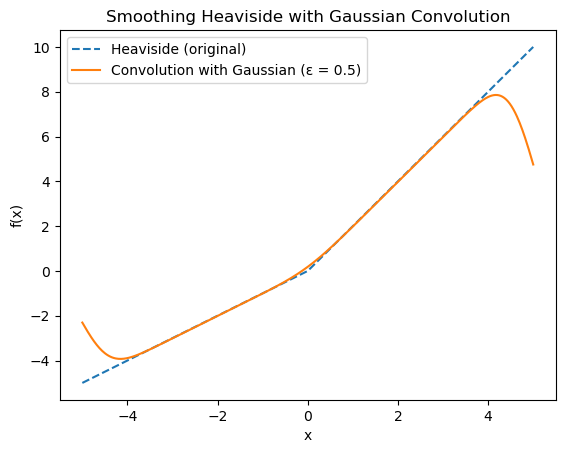

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the Heaviside step function
def heaviside(x):
    return np.where(x < 0, x, 2*x)

# Define a smooth kernel (using a normal distribution here) 
def gaussian_kernel(x, epsilon):
    return 1/(np.sqrt(2 * np.pi) * epsilon) * np.exp(-x**2 / (2 * epsilon**2))

# Perform convolution manually
def smooth_step(x_vals, epsilon):
    kernel_vals = gaussian_kernel(x_vals, epsilon)
    kernel_vals /= kernel_vals.sum()
    step_vals = heaviside(x_vals)
    smoothed = np.convolve(step_vals, kernel_vals, mode='same')
    return smoothed

# Set up range and epsilon
x_vals = np.linspace(-5, 5, 500)
epsilon = 0.5

# Smooth the step
smoothed_vals = smooth_step(x_vals, epsilon)

# Plot
plt.plot(x_vals, heaviside(x_vals), label='Heaviside (original)', linestyle='--')
plt.plot(x_vals, smoothed_vals, label=f'Convolution with Gaussian (ε = {epsilon})')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Smoothing Heaviside with Gaussian Convolution')
plt.show()
